[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/infer-actively/pymdp/blob/docs/add-beginner-notebook/examples/beginner/thermostat_intro.ipynb)

# Active Inference as a Bayesian Thermostat

Every thermostat solves a control problem: keep the temperature near a setpoint by switching heating and cooling on and off. The standard approach (bang-bang control) reads the thermometer and reacts directly: too cold -> heat, too warm -> cool.

The problem: thermometers are noisy. A single reading that says *cold* might actually mean the room is comfortable. A bang-bang controller treats every reading as ground truth and oscillates, sometimes heating or cooling in entirely the wrong direction.

A **Bayesian thermostat** does something different: it maintains a *belief distribution* over the true temperature, updated from every noisy reading via Bayes' rule, and acts on that belief rather than the raw sensor value. This is exactly what active inference gives you. The result: smoother regulation, fewer noise-driven mistakes, and action strength automatically calibrated to sensor quality.

This notebook builds the Bayesian thermostat from the four active inference matrices (A, B, C, D), runs it, and compares it directly to a bang-bang controller on the same environment.

In [ ]:
import sys
if "google.colab" in sys.modules:
    %pip install "inferactively-pymdp" -q

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

from pymdp.agent import Agent
from pymdp.distribution import compile_model

## Why bang-bang thermostats are noisy

A bang-bang controller implements a simple rule:

```python
if thermometer.read() < setpoint:
    heater.on()
else:
    heater.off()
```

This works if the thermometer is perfect. In practice, thermometers have noise: a room at *comfortable* might read *cold* 25% of the time. The bang-bang controller reacts immediately, turning on the heater for no reason. The true temperature was already comfortable, so the room overshoots to warm. The controller then reacts to that, and so on, oscillation driven entirely by sensor noise.

The fix is to not act on the reading directly, but on a *belief* about the true temperature that is informed by many readings over time. This is what Bayesian filtering does, and expected free energy minimisation gives you Bayesian filtering plus optimal action selection in the same framework.

**Connection to Kalman filters:** in a linear Gaussian world, this is exactly the Kalman filter + LQR combination (optimal filtering + optimal control). Active inference is the generalisation to non-linear, non-Gaussian, discrete settings.

## The world

```
Hidden state:  temperature ∈ {very_cold, cold, comfortable, warm, very_warm}

Actions:
  heat  →  advance temperature one step warmer (70%),  stay (30%)
  wait  →  stay (60%),  drift one step cooler (30%),  drift warmer (10%)
  cool  →  advance temperature one step cooler (70%),  stay (30%)

Observation (thermometer reading): noisy version of true temperature
  Gaussian blur with σ = 1 state:  correct reading (40%),  ±1 confusion (35% total), ±2 (20%), ...

Preferences (C):  comfortable → +3,  cold/warm → −1,  extremes → −3
```

The epistemic challenge here is how much to *trust* the measurement, and how to effectively act on an uncertain perception of the environment.

In [1]:
temp_states    = ["very_cold", "cold", "comfortable", "warm", "very_warm"]
action_labels  = ["heat", "wait", "cool"]
reading_labels = ["reads_very_cold", "reads_cold", "reads_comfortable", "reads_warm", "reads_very_warm"]

model_spec = {
    "observations": {
        "reading": {
            "elements": reading_labels,
            "depends_on": ["temperature"],
        }
    },
    "controls": {"action": {"elements": action_labels}},
    "states": {
        "temperature": {
            "elements": temp_states,
            "depends_on": ["temperature"],
            "controlled_by": ["action"],
        }
    },
}
model = compile_model(model_spec)

# ── A: noisy thermometer — Gaussian confusion between adjacent states ──────────
# sigma=1.0: the reading is usually right but ±1 state errors are common
sigma = 1.0
for j in range(5):
    weights = np.array([np.exp(-0.5 * ((i - j) / sigma)**2) for i in range(5)])
    model.A["reading"].data[:, j] = weights / weights.sum()

# ── B: stochastic thermal dynamics ────────────────────────────────────────────
# heat: 70% advance one step warmer, 30% stay (ceiling at very_warm)
for j in range(5):
    model.B["temperature"].data[min(j + 1, 4), j, 0] += 0.7
    model.B["temperature"].data[j, j, 0] += 0.3

# wait: 60% stay, 30% drift cooler (house loses heat), 10% drift warmer
for j in range(5):
    model.B["temperature"].data[j, j, 1] += 0.6
    model.B["temperature"].data[max(j - 1, 0), j, 1] += 0.3
    model.B["temperature"].data[min(j + 1, 4), j, 1] += 0.1

# cool: 70% advance one step cooler, 30% stay (floor at very_cold)
for j in range(5):
    model.B["temperature"].data[max(j - 1, 0), j, 2] += 0.7
    model.B["temperature"].data[j, j, 2] += 0.3

# ── C: symmetric preference centred on comfortable ────────────────────────────
model.C["reading"].data = np.array([-3.0, -1.0, 3.0, -1.0, -3.0])

# ── D: uniform — thermostat doesn't know the starting temperature ─────────────
# (default from compile_model is already uniform)

print("Model compiled.")
print(f"  A shape : {model.A['reading'].data.shape}   (reading x true_temperature)")
print(f"  B shape : {model.B['temperature'].data.shape}  (new_temp x old_temp x action)")
print(f"  C       : {model.C['reading'].data}")
print(f"  D       : {model.D['temperature'].data}")

Model compiled.
  A shape : (5, 5)   (reading × true_temperature)
  B shape : (5, 5, 3)  (new_temp × old_temp × action)
  C       : [-3. -1.  3. -1. -3.]
  D       : [0.2 0.2 0.2 0.2 0.2]


<Figure size 1300x400 with 0 Axes>

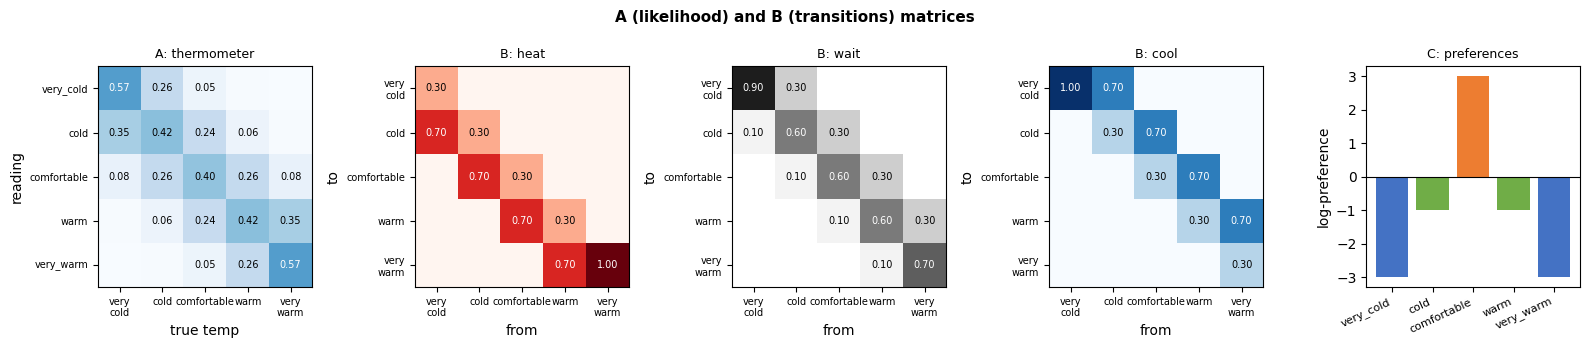

In [2]:
def annotate(ax, data):
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = float(data[r, c])
            if v > 0.02:
                ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if v > 0.45 else "black")

# ── Figure 1: A matrix ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Generative model matrices", fontsize=12, fontweight="bold")

A = model.A["reading"].data
ax = axes[0]
ax.imshow(A, vmin=0, vmax=1, cmap="Blues", aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(temp_states, rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(5)); ax.set_yticklabels(reading_labels, fontsize=8)
ax.set_title("A — thermometer likelihood\n(columns sum to 1)", fontsize=10)
ax.set_xlabel("true temperature"); ax.set_ylabel("observed reading")
annotate(ax, A)

# ── Figure 2: B matrices (3 action slices side by side) ──────────────────────
B = model.B["temperature"].data
action_cmaps = ["Reds", "Greys", "Blues"]
for i, (a, cmap) in enumerate(zip(action_labels, action_cmaps)):
    ax = axes[1] if i == 0 else fig.add_subplot(1, 5, 3 + i)
fig.clf()
fig, axes2 = plt.subplots(1, 5, figsize=(16, 3.5))
fig.suptitle("A (likelihood) and B (transitions) matrices", fontsize=11, fontweight="bold")

ax = axes2[0]
ax.imshow(A, vmin=0, vmax=1, cmap="Blues", aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels([s.replace("_","\n") for s in temp_states], fontsize=7)
ax.set_yticks(range(5)); ax.set_yticklabels([r.replace("reads_","") for r in reading_labels], fontsize=7)
ax.set_title("A: thermometer", fontsize=9); ax.set_xlabel("true temp")
ax.set_ylabel("reading")
annotate(ax, A)

for i, (a, cmap) in enumerate(zip(action_labels, ["Reds", "Greys", "Blues"])):
    ax = axes2[i + 1]
    ax.imshow(B[:, :, i], vmin=0, vmax=1, cmap=cmap, aspect="auto")
    ax.set_xticks(range(5)); ax.set_xticklabels([s.replace("_","\n") for s in temp_states], fontsize=7)
    ax.set_yticks(range(5)); ax.set_yticklabels([s.replace("_","\n") for s in temp_states], fontsize=7)
    ax.set_title(f"B: {a}", fontsize=9); ax.set_xlabel("from"); ax.set_ylabel("to")
    annotate(ax, B[:, :, i])

# C preference curve
ax = axes2[4]
colors = ["#4472C4", "#70AD47", "#ED7D31", "#70AD47", "#4472C4"]
ax.bar(range(5), model.C["reading"].data, color=colors)
ax.set_xticks(range(5))
ax.set_xticklabels([r.replace("reads_","") for r in reading_labels], rotation=25, ha="right", fontsize=8)
ax.set_title("C: preferences", fontsize=9); ax.set_ylabel("log-preference")
ax.axhline(0, color="black", linewidth=0.8)

fig.tight_layout()
plt.show()

In [3]:
T = 3

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    agent = Agent(**model, gamma=16.0, policy_len=T)

print(f"policies : {agent.policies.policy_arr.shape}"
      f"  →  {agent.policies.policy_arr.shape[0]} candidate plans of length "
      f"{agent.policies.policy_arr.shape[1]}")

policies : (27, 3, 1)  →  27 candidate plans of length 3


## One step

The thermostat is turned on without knowing the starting temperature (uniform prior). It reads `reads_very_cold` from the thermometer. What should it do?

Effective Free Energy (G) scores each candidate T-step policy. The optimal policy is the one with the *lowest negative G* 

In [4]:
READING = {l: i for i, l in enumerate(reading_labels)}
TEMP    = {l: i for i, l in enumerate(temp_states)}

obs   = jnp.array([READING["reads_very_cold"]])
prior = agent.D

qs = agent.infer_states([obs], prior)

print("Posterior over temperature after reads_very_cold (uniform prior):")
beliefs = np.array(qs[0][0, 0])
for s, p in zip(temp_states, beliefs):
    print(f"  P({s:12s}) = {p:.3f}")
print("  → shifted toward cold end, but still spread — the reading is noisy.\n")

q_pi, neg_efe = agent.infer_policies(qs)
policies   = agent.policies.policy_arr
neg_efe_np = np.array(neg_efe[0])

print("Mean EFE (G) by first action:")
for i, a in enumerate(action_labels):
    mask = policies[:, 0, 0] == i
    print(f"  {a:6s} →  G = {neg_efe_np[mask].mean():.3f}")

action = agent.sample_action(q_pi)
print(f"\n→ Agent picks: {action_labels[int(action[0, 0])]}")
print("  (G values are all negative from a cold uncertain start, but heat is least bad —")
print("  it's the fastest path toward comfortable observations.)") 

Posterior over temperature after reads_very_cold (uniform prior):
  P(very_cold   ) = 0.643
  P(cold        ) = 0.290
  P(comfortable ) = 0.061
  P(warm        ) = 0.005
  P(very_warm   ) = 0.000
  → shifted toward cold end, but still spread — the reading is noisy.

Mean EFE (G) by first action:
  heat   →  G = -1.457
  wait   →  G = -3.165
  cool   →  G = -3.893

→ Agent picks: heat
  (G values are all negative from a cold uncertain start, but heat is least bad —
  it's the fastest path toward comfortable observations.)


## Full episode

Run the thermostat for 15 steps from a very cold starting temperature. The thermostat's prior is uniform — it doesn't know the starting temperature. The belief column shows where the thermostat *thinks* it is; the true temp column shows where it actually is. The noisy A matrix means these won't always match.

In [5]:
def run_episode(agent, model, true_start="very_cold", steps=15, seed=42):
    rng      = np.random.default_rng(seed)
    true_t   = TEMP[true_start]
    prior    = agent.D
    obs_idx  = int(rng.choice(5, p=model.A["reading"].data[:, true_t]))

    true_temps, readings, actions, beliefs = [], [], [], []

    for t in range(steps):
        true_temps.append(true_t)
        readings.append(obs_idx)

        obs = jnp.array([obs_idx])
        qs  = agent.infer_states([obs], prior)
        beliefs.append(np.array(qs[0][0, 0]))

        q_pi, _ = agent.infer_policies(qs)
        action  = agent.sample_action(q_pi)
        act_i   = int(action[0, 0])
        actions.append(act_i)

        true_t  = int(rng.choice(5, p=model.B["temperature"].data[:, true_t, act_i]))
        obs_idx = int(rng.choice(5, p=model.A["reading"].data[:, true_t]))
        prior   = agent.update_empirical_prior(action, qs)

    return true_temps, readings, actions, np.array(beliefs)


true_temps, readings, actions, beliefs = run_episode(agent, model)

print(f"{'t':>3}  {'true_temp':14}  {'reading':22}  {'action':6}  {'belief_mode'}")
print("-" * 70)
for t in range(len(actions)):
    note = "  ← noisy!" if temp_states[true_temps[t]] != reading_labels[readings[t]].replace("reads_","") else ""
    print(f"{t:>3}  {temp_states[true_temps[t]]:14}  {reading_labels[readings[t]]:22}  "
          f"{action_labels[actions[t]]:6}  {temp_states[np.argmax(beliefs[t])]}{note}")

  t  true_temp       reading                 action  belief_mode
----------------------------------------------------------------------
  0  very_cold       reads_cold              heat    cold  ← noisy!
  1  cold            reads_comfortable       heat    comfortable  ← noisy!
  2  comfortable     reads_cold              heat    comfortable  ← noisy!
  3  warm            reads_very_warm         cool    warm  ← noisy!
  4  warm            reads_comfortable       cool    comfortable  ← noisy!
  5  comfortable     reads_comfortable       heat    comfortable
  6  warm            reads_warm              cool    warm
  7  warm            reads_warm              cool    comfortable
  8  comfortable     reads_comfortable       heat    comfortable
  9  comfortable     reads_warm              cool    warm  ← noisy!
 10  cold            reads_comfortable       wait    comfortable  ← noisy!
 11  cold            reads_warm              cool    comfortable  ← noisy!
 12  cold            reads_comfo

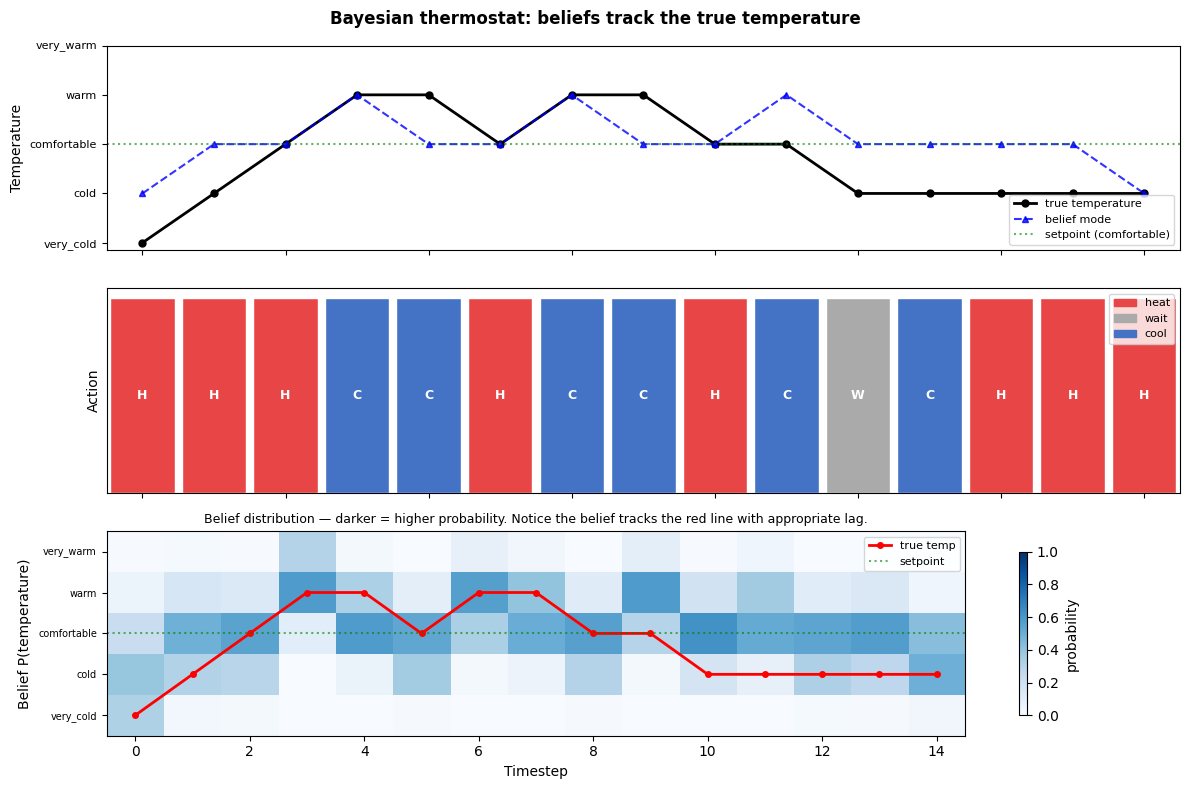

In [6]:
T  = len(actions)
ts = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Bayesian thermostat: beliefs track the true temperature",
             fontsize=12, fontweight="bold")

# ── Panel 1: true temperature and belief mode ─────────────────────────────────
ax1 = axes[0]
ax1.plot(ts, true_temps,  "k-o", linewidth=2, label="true temperature", markersize=5)
ax1.plot(ts, [np.argmax(b) for b in beliefs], "b--^", linewidth=1.5,
         label="belief mode", alpha=0.8, markersize=5)
ax1.axhline(2, color="green", linestyle=":", alpha=0.6, label="setpoint (comfortable)")
ax1.set_yticks(range(5)); ax1.set_yticklabels(temp_states, fontsize=8)
ax1.legend(fontsize=8, loc="lower right")
ax1.set_ylabel("Temperature")

# ── Panel 2: actions ──────────────────────────────────────────────────────────
ax2 = axes[1]
action_colors = {"heat": "#e84646", "wait": "#aaaaaa", "cool": "#4472C4"}
for t, ai in enumerate(actions):
    a = action_labels[ai]
    ax2.bar(t, 1, color=action_colors[a], edgecolor="white", width=0.9)
    ax2.text(t, 0.5, a[0].upper(), ha="center", va="center",
             fontsize=9, color="white", fontweight="bold")
ax2.set_yticks([]); ax2.set_ylabel("Action")
patches = [mpatches.Patch(color=c, label=a) for a, c in action_colors.items()]
ax2.legend(handles=patches, loc="upper right", fontsize=8)

# ── Panel 3: belief heatmap ───────────────────────────────────────────────────
ax3 = axes[2]
im = ax3.imshow(beliefs.T, aspect="auto", cmap="Blues", vmin=0, vmax=1,
                extent=[-0.5, T - 0.5, -0.5, 4.5], origin="lower")
ax3.plot(ts, true_temps, "r-o", linewidth=2, markersize=4, label="true temp")
ax3.axhline(2, color="green", linestyle=":", alpha=0.6, label="setpoint")
ax3.set_yticks(range(5)); ax3.set_yticklabels(temp_states, fontsize=7)
ax3.set_xlabel("Timestep"); ax3.set_ylabel("Belief P(temperature)")
ax3.legend(fontsize=8)
plt.colorbar(im, ax=ax3, shrink=0.8, label="probability")
ax3.set_title("Belief distribution — darker = higher probability. "
              "Notice the belief tracks the red line with appropriate lag.",
              fontsize=9)

fig.tight_layout()
plt.show()

## Bayesian thermostat vs bang-bang

A bang-bang controller reads the thermometer and reacts directly:

```python
if reading < comfortable: heat
elif reading > comfortable: cool
else: wait
```

It has no memory of past readings and no model of sensor noise. Every noisy reading triggers an immediate reaction. The Bayesian thermostat maintains a posterior, noisy readings are down-weighted by the prior, and actions are chosen based on beliefs, not raw sensor values.

Run both from the same starting conditions and compare. Look for steps where the bang-bang controller acts in the **wrong direction** because of a noisy reading.

  t               BAYESIAN                           BANG-BANG             
     true         action  true         action  note
--------------------------------------------------------------------------------
  0  very_cold    heat      very_cold    heat  
  1  cold         heat      cold         wait  
  2  comfortable  heat      cold         heat  
  3  warm         cool      comfortable  cool  
  4  warm         cool      comfortable  heat  
  5  comfortable  heat      warm         cool  
  6  warm         cool      warm         cool  
  7  warm         cool      warm         cool  
  8  comfortable  heat      comfortable  wait  
  9  comfortable  cool      cold         wait  
 10  cold         wait      cold         wait  
 11  cold         cool      cold         cool   <- BB cools when cold!
 12  cold         heat      cold         wait  
 13  cold         heat      very_cold    heat  
 14  cold         heat      very_cold    heat  


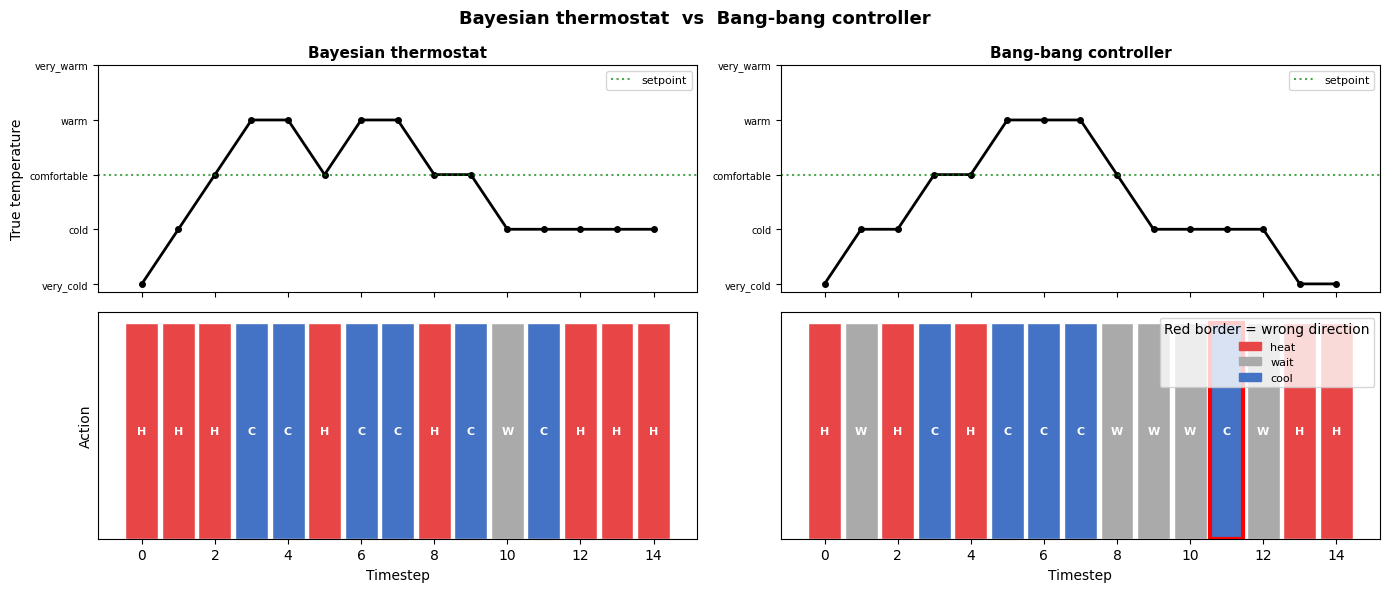

In [7]:
def run_bangbang(model, true_start="very_cold", steps=15, seed=42):
    rng     = np.random.default_rng(seed)
    true_t  = TEMP[true_start]
    obs_idx = int(rng.choice(5, p=model.A["reading"].data[:, true_t]))
    true_temps, readings, actions = [], [], []

    for _ in range(steps):
        true_temps.append(true_t)
        readings.append(obs_idx)
        # bang-bang: react directly to reading
        if obs_idx < 2:    act_i = 0  # heat
        elif obs_idx > 2:  act_i = 2  # cool
        else:              act_i = 1  # wait
        actions.append(act_i)
        true_t  = int(rng.choice(5, p=model.B["temperature"].data[:, true_t, act_i]))
        obs_idx = int(rng.choice(5, p=model.A["reading"].data[:, true_t]))

    return true_temps, readings, actions


bb_temps, bb_readings, bb_actions = run_bangbang(model)

# ── Print both trajectories with errors highlighted ───────────────────────────
comfortable_i = TEMP["comfortable"]
print(f"{'t':>3}  {'BAYESIAN':^34}  {'BANG-BANG':^34}")
print(f"     {'true':12} {'action':6}  {'true':12} {'action':6}  note")
print("-" * 80)
for t in range(len(actions)):
    bi_true = temp_states[true_temps[t]]
    bi_act  = action_labels[actions[t]]
    bb_true = temp_states[bb_temps[t]]
    bb_act  = action_labels[bb_actions[t]]
    # flag: wrong-direction action (cool when cold, heat when warm)
    bb_err = ""
    if bb_temps[t] < comfortable_i and bb_actions[t] == 2: bb_err = " <- BB cools when cold!"
    if bb_temps[t] > comfortable_i and bb_actions[t] == 0: bb_err = " <- BB heats when warm!"
    print(f"{t:>3}  {bi_true:12} {bi_act:8}  {bb_true:12} {bb_act:6}{bb_err}")

# ── Side-by-side trajectory plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
fig.suptitle("Bayesian thermostat  vs  Bang-bang controller",
             fontsize=13, fontweight="bold")

action_colors = {"heat": "#e84646", "wait": "#aaaaaa", "cool": "#4472C4"}

for col, (t_arr, a_arr, b_arr, title) in enumerate([
    (true_temps, actions,    beliefs,   "Bayesian thermostat"),
    (bb_temps,   bb_actions, None,      "Bang-bang controller"),
]):
    T_c = len(a_arr)
    ax1 = axes[0, col]
    ax1.plot(range(T_c), t_arr, "k-o", linewidth=2, markersize=4)
    ax1.axhline(comfortable_i, color="green", linestyle=":", alpha=0.7, label="setpoint")
    ax1.set_yticks(range(5)); ax1.set_yticklabels(temp_states, fontsize=7)
    ax1.set_title(title, fontsize=11, fontweight="bold")
    ax1.set_ylabel("True temperature" if col == 0 else "")
    ax1.legend(fontsize=8)

    ax2 = axes[1, col]
    for t, ai in enumerate(a_arr):
        a = action_labels[ai]
        ax2.bar(t, 1, color=action_colors[a], edgecolor="white", width=0.9)
        ax2.text(t, 0.5, a[0].upper(), ha="center", va="center",
                 fontsize=8, color="white", fontweight="bold")
        # highlight wrong-direction actions in bang-bang
        if col == 1:
            if t_arr[t] < comfortable_i and ai == 2:
                ax2.bar(t, 1.0, color="none", edgecolor="red", linewidth=3, width=0.9)
            if t_arr[t] > comfortable_i and ai == 0:
                ax2.bar(t, 1.0, color="none", edgecolor="red", linewidth=3, width=0.9)
    ax2.set_yticks([])
    ax2.set_ylabel("Action" if col == 0 else "")
    ax2.set_xlabel("Timestep")

patches = [mpatches.Patch(color=c, label=a) for a, c in action_colors.items()]
axes[1, 1].legend(handles=patches, loc="upper right", fontsize=8,
                  title="Red border = wrong direction")
fig.tight_layout()
plt.show()

## Takeaways

- **Beliefs smooth out sensor noise.** The Bayesian thermostat maintains a posterior distribution over temperature — a single noisy reading is down-weighted by the prior rather than acted on immediately. Bang-bang has no such filter.
- **Action strength is calibrated to uncertainty.** With a spread-out posterior, the agent acts conservatively. As beliefs converge, it acts more decisively. A bang-bang controller has no such calibration, every reading triggers a full reaction.
- **Connection to classical control.** Bang-bang is a zero-memory threshold controller. PID adds integral and derivative terms for smoother response but still assumes you observe the true state. Active inference maintains a full posterior and plans ahead i.e. it generalises PID to partially observable settings.
- **Wrong-direction actions come from reading noise, not model errors.** The red-bordered bars in the bang-bang plot are cases where the reading misled the controller. The Bayesian thermostat avoids them because it propagates uncertainty before acting.